## Building Basic Chatbot using Langgraph (Graph API)

In [1]:
import os
from dotenv import load_dotenv

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API"))

In [13]:
llm2=init_chat_model("groq:llama-3.1-8b-instant", api_key=os.getenv("GROQ_API"))

In [5]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)

In [6]:
def chatbot_node(state:State):
    return{"messages":[llm2.invoke(state["messages"])]}

In [7]:
# building state graph

# adding nodes
graph_builder.add_node("llmbasicbot",chatbot_node)

# adding edges
graph_builder.add_edge(START,"llmbasicbot")
graph_builder.add_edge("llmbasicbot",END)

# compiling graph

graph=graph_builder.compile()



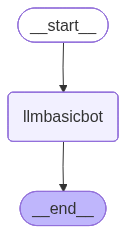

In [8]:
## visualising graph 
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error Occured : {e}")

In [15]:
responses=graph.invoke({"messages":"Hi"})

In [16]:
responses=graph.invoke({"messages":"what is AI"})

In [22]:
responses["messages"][-1]

AIMessage(content="AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of developing algorithms and statistical models that enable machines to perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experiences, or interactions.\n2. **Reasoning**: AI systems can draw conclusions, make decisions, or solve problems based on the available data.\n3. **Problem-solving**: AI systems can identify and solve complex problems, often in situations that require a high degree of autonomy.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, or text.\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Desig

In [ ]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    print (events)


{'llmbasicbot': {'messages': [AIMessage(content="I'm just a language model, so I don't have emotions or feelings like humans do, but I'm functioning properly and ready to help you with any questions or tasks you may have. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 41, 'total_tokens': 87, 'completion_time': 0.061041603, 'completion_tokens_details': None, 'prompt_time': 0.003094223, 'prompt_tokens_details': None, 'queue_time': 0.052153749, 'total_time': 0.064135826}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed375-5289-79d0-8b0f-dc947faa8fe0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 46, 'total_tokens': 87})]}}


In [24]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values)


{'messages': [AIMessage(content="I'm functioning properly and ready to assist you with any questions or information you need. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 41, 'total_tokens': 66, 'completion_time': 0.032847557, 'completion_tokens_details': None, 'prompt_time': 0.001919263, 'prompt_tokens_details': None, 'queue_time': 0.05074633, 'total_time': 0.03476682}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed376-095d-7c53-803c-d26d1b4506e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 25, 'total_tokens': 66})]}


In [26]:
for events in graph.stream({"messages":"Hey! How are you?"}):
    for values in events.values():
        print (values["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. Is there anything specific you'd like to talk about or ask?
